# Multi-SpaCE Implementation Comparison — SpokenArabicDigits

`cfts/cf_multispace/multispace.py` implements **Multi-SpaCE** (Refoyo & Luengo, 2025,
"Multi-SpaCE: Multi-Objective Subsequence-based Sparse Counterfactual Explanations for
Multivariate Time Series Classification", [arXiv:2501.04009](https://arxiv.org/abs/2501.04009),
[HTML](https://arxiv.org/html/2501.04009v2); official repository:
[MarioRefoyo/Multi-SpaCE](https://github.com/MarioRefoyo/Multi-SpaCE)).

Multi-SpaCE extends Sub-SpaCE (see `cfts/cf_subspace/subspace_forda_comparison.ipynb`) to
**multivariate** time series and replaces its single weighted-sum fitness with a genuine
**multi-objective genetic algorithm** (NSGA-II): a binary mask selects which (time step,
channel) entries of the query get replaced by the corresponding entries of its **Nearest
Unlike Neighbor** (NUN), and the population is optimized simultaneously over four objectives
— target-class probability, sparsity, number of contiguous subsequences, and an
autoencoder-based plausibility term — with invalid candidates penalized so hard they fall
off the Pareto front entirely. The paper's headline claim is that treating validity as a
**strict constraint** rather than a soft objective is what lets it reach 100% validity while
competing methods fall below 50% on many datasets. Optimization runs in **three stages**: a
"grouped" stage where all channels share one temporal mask (cheap, coarse), an optional
"individual" stage where each channel gets its own mask, and a final "pruning" stage that
removes now-unnecessary subsequences — each stage seeding its population from the previous
stage's Pareto front.

This notebook:
1. Loads **SpokenArabicDigits** (multivariate, 13 channels, 65 time steps, 10 classes — UCR/UEA
   archive) and the repo's pretrained `SimpleCNNMulti`, so Multi-SpaCE's actual differentiator
   (multivariate support) is exercised, unlike the univariate FordA used in the other
   comparison notebooks in this repo.
2. Clones the official repository and drives its **unmodified** core algorithm
   (`MultiSubSpaCECF`, the full grouped→individual→pruning NSGA-II pipeline) via a thin PyTorch
   adapter, following the same pattern as `cfts/cf_subspace/subspace_forda_comparison.ipynb`
   and `cfts/cf_comte/comte_forda_comparison.ipynb`.
3. Walks through a single Multi-SpaCE call in detail for all three variants, including the
   Pareto fronts of solutions `multispace_cf`/`multispace_official` return (something
   `multispace_fast` has no concept of).
4. Compares `multispace_cf`, `multispace_fast` (both this repo), and the vendored official
   algorithm on the same model and data, and explicitly checks whether each matches the
   published algorithm.

| Variant | Source | Notes |
|---|---|---|
| `multispace_cf` | `cfts/cf_multispace/multispace.py` | This repo's **canonical** Multi-SpaCE implementation. Ports the official repo's **NSGA-II** algorithm: a real `AutoencoderOutlierCalculator` plausibility term, `fitness_function_mo`'s 4-objective non-dominated sorting + crowding distance, and the boundary-aware mutation operators, run as a grouped→pruning staged pipeline matching the paper's own recommended `multisubspace_final.json` hyperparameters. Returns a **Pareto front** (or its sparsest valid member, by default) just like the vendored code. |
| `multispace_fast` | `cfts/cf_multispace/multispace.py` | Same PyTorch entry-point convenience as `multispace_cf`, but adapted for speed. Explicitly documented in its own docstring as *"a simplified implementation of Multi-SpaCE"*. Single population, single scalar weighted-sum fitness (`validity_weight * validity + sparsity_weight * (...)`), no multi-objective machinery, no plausibility term, no staged pipeline, GradientShap-guided init, coin-flip-per-element mutation. |
| `multispace_official` | Vendored `MultiSubSpaCECF` / `MOEvolutionaryOptimizer` family / `fitness_function_mo` from [MarioRefoyo/Multi-SpaCE](https://github.com/MarioRefoyo/Multi-SpaCE), driven by a thin PyTorch adapter written for this notebook | Runs the literal published NSGA-II algorithm: grouped→pruning staged search (the paper's "final" config skips the individual-channel stage), 4-objective Pareto front (validity / sparsity / contiguity / plausibility), a real autoencoder-based plausibility term, and validity enforced as a hard constraint via `invalid_penalization`. Returns a **whole Pareto front** of valid counterfactuals per call, not a single point. `multispace_cf` is this repo's own implementation of this exact strategy, so close agreement between the two here is evidence it's a faithful port. |

In [1]:
from __future__ import annotations

import random
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import f1_score

warnings.filterwarnings("ignore")

# Locate repo root
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "cfts").exists():
        sys.path.insert(0, str(candidate))
        sys.path.insert(0, str(candidate / "examples"))
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate repository root containing cfts/")

from base.data import get_UCR_UEA_dataloader
from base.model import SimpleCNNMulti
from cfts.cf_multispace.multispace import multispace_cf, multispace_fast
from cfts.metrics import l2_distance, dtw_distance, normalized_distance, percentage_changed_points

plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Repo root: {REPO_ROOT}")

Using device: cpu
Repo root: /workspaces/counterfactual-explanations-for-time-series


In [2]:
# Load SpokenArabicDigits dataset and pretrained model
_, dataset_train = get_UCR_UEA_dataloader(dataset_name="SpokenArabicDigits", split="train")
_, dataset_test = get_UCR_UEA_dataloader(dataset_name="SpokenArabicDigits", split="test")

output_classes = dataset_train.y_shape[1]
C, L = dataset_train.X_shape[1], dataset_train.X_shape[2]

model = SimpleCNNMulti(input_channels=C, output_channels=output_classes, sequence_length=L).to(device)

model_path = REPO_ROOT / "models" / f"cnn_multi_arabicdigits_{output_classes}ch.pth"
if not model_path.exists():
    raise FileNotFoundError(
        f"Pretrained model not found at {model_path}.\n"
        "Run examples/example_multivariate.py first to train and save the model."
    )

state = torch.load(model_path, map_location=device)
model.load_state_dict(state)
model.eval()
print(f"Loaded model from {model_path}")


def predict_scores(model, sample, device):
    """(...,) -> (n_classes,) post-softmax probs. SimpleCNNMulti has no built-in softmax
    (unlike SimpleCNN, used by the other comparison notebooks), so it is applied here."""
    ts = torch.tensor(np.asarray(sample, dtype=np.float32), device=device)
    if ts.ndim == 2:
        ts = ts.unsqueeze(0)
    with torch.no_grad():
        logits = model(ts)
        return torch.softmax(logits, dim=1).detach().cpu().numpy().reshape(-1)


def to_class_index(label):
    arr = np.asarray(label)
    return int(np.argmax(arr)) if arr.ndim > 0 else int(arr)


def to_channel_first(sample):
    """(...,) -> (C, L)."""
    arr = np.asarray(sample, dtype=np.float32)
    return arr if arr.shape[0] <= arr.shape[1] else arr.T


def to_channel_last(sample):
    """(...,) -> (L, C)."""
    return to_channel_first(sample).T


y_true, y_pred = [], []
for sample, label in dataset_test:
    scores = predict_scores(model, sample, device)
    y_true.append(to_class_index(label))
    y_pred.append(int(np.argmax(scores)))

test_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Train size: {len(dataset_train)} | Test size: {len(dataset_test)}")
print(f"Channels: {C} | Length: {L} | Classes: {output_classes}")
print(f"Test macro F1: {test_f1:.4f}")

Loaded model from /workspaces/counterfactual-explanations-for-time-series/models/cnn_multi_arabicdigits_10ch.pth


Train size: 6599 | Test size: 2199
Channels: 13 | Length: 65 | Classes: 10
Test macro F1: 0.9850


## Official Multi-SpaCE baseline (MarioRefoyo/Multi-SpaCE)

Clone the authors' own code as described below (skipped gracefully if not present). It is a
large mono-repo (~250MB) also containing several *other* baselines' code (CoMTE, Glacier,
DiscoX, ...) it was benchmarked against, and a "v2" variant of Multi-SpaCE itself
(`MultiSubSpaCECFv2` / `multisubspacev2.py`) that post-dates and is **not** described in the
arXiv paper fetched above — this notebook vendors and compares against **v1**
(`MultiSubSpaCECF`), which is what the paper describes, using its own recommended
`experiments/params_cf/multisubspace_final.json` hyperparameters.

```bash
mkdir -p cfts/cf_multispace/external
git clone --depth 1 https://github.com/MarioRefoyo/Multi-SpaCE.git cfts/cf_multispace/external/multispace_github
```

Unlike Sub-SpaCE's official repo (where the optimizer/fitness code is pure numpy but the outer
`SubSpaCECF` wrapper is hard-wired to Keras), Multi-SpaCE's `methods/MultiSubSpaCECF.py`,
`methods/MultiSubSpaCE/MOEvolutionaryOptimizers.py`, and
`methods/MultiSubSpaCE/FitnessFunctions.py` have **zero TensorFlow/PyTorch imports at all** —
the backend only enters through two swappable dependencies passed in by the caller:

- **`model_wrapper`**: `CounterfactualMethod.predict_function` just calls
  `self.model_wrapper.predict(inputs)`, so a thin PyTorch object exposing `.predict(...)` is a
  complete, unmodified-code-compatible substitute (same pattern as `cfts/cf_comte`'s
  `CNNClfAdapter` and `cfts/cf_subspace`'s official-run adapter).
- **`outlier_calculator`**: the vendored `AEOutlierCalculator` wraps a **Keras** model in a
  `tf.function`, so we don't reuse it directly -- instead we reimplement its exact scoring math
  (mean absolute reconstruction error, scaled by `(x - min(0, calib_min)) / calib_max`) around a
  real trained **PyTorch** autoencoder.
- **`fi_method`**: the paper's own `multisubspace_final.json` sets `init_fi: "none"`, i.e. the
  published "final" config already **disables** feature-importance-guided initialization in
  favor of plain random init (`init_pct=0.2`). This means the vendored `NoneFI` class -- which
  has no backend dependency at all (`np.zeros(instance.shape)`) -- can be imported and used
  completely unmodified, with no PyTorch/Keras portability compromise needed here (contrast
  with Sub-SpaCE's official run, which had to skip the vendored Grad-CAM++ heatmap entirely).

So this notebook's `multispace_official` runs the literal vendored `MultiSubSpaCECF` class --
grouped/individual/pruning staging, NSGA-II non-dominated sorting and crowding-distance
selection, all four mutation operators, the real fitness functions -- unmodified, end to end.

In [3]:
EXTERNAL_MULTISPACE_DIR = REPO_ROOT / "cfts" / "cf_multispace" / "external" / "multispace_github"

HAVE_ORIGINAL_MULTISPACE = EXTERNAL_MULTISPACE_DIR.exists()

if HAVE_ORIGINAL_MULTISPACE:
    sys.path.insert(0, str(EXTERNAL_MULTISPACE_DIR))
    try:
        from methods.MultiSubSpaCECF import MultiSubSpaCECF
        from methods.MultiSubSpaCE.FeatureImportanceInitializers import NoneFI
        print(f"Loaded official Multi-SpaCE algorithm modules from {EXTERNAL_MULTISPACE_DIR}")
    except ImportError as exc:
        HAVE_ORIGINAL_MULTISPACE = False
        print(f"Found {EXTERNAL_MULTISPACE_DIR} but failed to import vendored modules ({exc}).")
else:
    print(
        f"{EXTERNAL_MULTISPACE_DIR} not found — skipping the multispace_official baseline.\n"
        "See the markdown cell above for the clone steps."
    )

Loaded official Multi-SpaCE algorithm modules from /workspaces/counterfactual-explanations-for-time-series/cfts/cf_multispace/external/multispace_github


In [4]:
# --- PyTorch model_wrapper: the only interface MultiSubSpaCECF needs is `.predict(batch_lc)`
#     returning post-softmax (N, n_classes) probs from an (N, L, C) channel-last batch. ---

class TorchModelWrapper:
    def __init__(self, model, device):
        self.model = model
        self.device = device

    def predict(self, batch_lc):
        batch_cl = np.transpose(np.asarray(batch_lc, dtype=np.float32), (0, 2, 1))  # (N,L,C) -> (N,C,L)
        x = torch.tensor(batch_cl, device=self.device)
        with torch.no_grad():
            logits = self.model(x)
            probs = torch.softmax(logits, dim=1)
        return probs.detach().cpu().numpy()


model_wrapper = TorchModelWrapper(model, device)


# --- PyTorch autoencoder + outlier calculator matching AEOutlierCalculator's exact scoring
#     math (methods/outlier_calculators.py), used for the "ios" (increase-in-outlier-score)
#     plausibility objective. ---

class _ConvAutoencoder1D(nn.Module):
    def __init__(self, channels, latent_channels=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(channels, 16, kernel_size=5, stride=2, padding=2), nn.ReLU(inplace=True),
            nn.Conv1d(16, latent_channels, kernel_size=5, stride=2, padding=2), nn.ReLU(inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(latent_channels, 16, kernel_size=5, stride=2, padding=2, output_padding=1), nn.ReLU(inplace=True),
            nn.ConvTranspose1d(16, channels, kernel_size=5, stride=2, padding=2, output_padding=1),
        )

    def forward(self, x):
        out = self.decoder(self.encoder(x))
        if out.shape[-1] != x.shape[-1]:
            out = nn.functional.interpolate(out, size=x.shape[-1], mode="linear", align_corners=False)
        return out


def train_autoencoder(calibration_cl, device, epochs=40, batch_size=64, lr=1e-3):
    """calibration_cl: (N, C, L) channel-first reference data."""
    N, Ch, _ = calibration_cl.shape
    ae = _ConvAutoencoder1D(Ch).to(device)
    opt = torch.optim.Adam(ae.parameters(), lr=lr)
    data_t = torch.tensor(calibration_cl, dtype=torch.float32, device=device)
    ae.train()
    for _ in range(epochs):
        perm = torch.randperm(N, device=device)
        for start in range(0, N, batch_size):
            batch = data_t[perm[start:start + batch_size]]
            opt.zero_grad()
            loss = torch.mean((ae(batch) - batch) ** 2)
            loss.backward()
            opt.step()
    ae.eval()
    return ae


class TorchAEOutlierCalculator:
    """Matches methods.outlier_calculators.AEOutlierCalculator exactly: mean absolute
    reconstruction error, scaled to [~0, 1] via (x - min(0, calib_min)) / calib_max."""

    def __init__(self, autoencoder, calibration_data_lc, device):
        self.autoencoder = autoencoder
        self.device = device
        self.length = calibration_data_lc.shape[1]
        self.n_channels = calibration_data_lc.shape[2]
        calibration_scores = self._get_raw_outlier_scores(calibration_data_lc)
        self.min_score = min(0, calibration_scores.min())
        self.max_score = calibration_scores.max()

    def _get_raw_outlier_scores(self, data):
        data = np.asarray(data, dtype=np.float32).reshape(-1, self.length, self.n_channels)
        x_lc = torch.tensor(data, device=self.device)
        x_cl = x_lc.permute(0, 2, 1)
        with torch.no_grad():
            recon_cl = self.autoencoder(x_cl)
        recon_lc = recon_cl.permute(0, 2, 1)
        errors = torch.mean(torch.abs(x_lc - recon_lc), dim=(1, 2))
        return errors.cpu().numpy()

    def get_outlier_scores(self, data):
        raw = self._get_raw_outlier_scores(data)
        scaled = (raw - self.min_score) / (self.max_score - self.min_score)
        return scaled.flatten()


BG_SIZE = 300
bg_idx = np.random.choice(len(dataset_train), BG_SIZE, replace=False)  # dataset is class-sorted; sample randomly
background_dataset = [
    (np.asarray(dataset_train[i][0], dtype=np.float32), np.asarray(dataset_train[i][1], dtype=np.float32))
    for i in bg_idx
]
print(f"Background dataset (NUN search / autoencoder calibration pool): {len(background_dataset)} samples")

if HAVE_ORIGINAL_MULTISPACE:
    calibration_cl = np.stack([to_channel_first(x) for x, _ in background_dataset], axis=0)  # (N, C, L)
    print(f"Training plausibility autoencoder on {len(calibration_cl)} reference samples...")
    ae_model = train_autoencoder(calibration_cl, device)
    calibration_lc = np.transpose(calibration_cl, (0, 2, 1))
    outlier_calculator_official = TorchAEOutlierCalculator(ae_model, calibration_lc, device)
    print(f"Outlier calculator calibrated: min={outlier_calculator_official.min_score:.4f} "
          f"max={outlier_calculator_official.max_score:.4f}")

Background dataset (NUN search / autoencoder calibration pool): 300 samples
Training plausibility autoencoder on 300 reference samples...


Outlier calculator calibrated: min=0.0000 max=0.9004


In [5]:
# Shared hyperparameters for the official run, matching experiments/params_cf/multisubspace_final.json
# (the paper's own recommended "final" setting) exactly.
MULTISPACE_HPARAMS = dict(
    population_size=100,
    change_subseq_mutation_prob=0.75,
    add_subseq_mutation_prob=0,
    integrated_pruning_mutation_prob=0,
    final_pruning_mutation_prob=0.75,
    init_pct=0.2, reinit=True, init_random_mix_ratio=0.5,
    invalid_penalization=100,
)
GROUPED_ITER, INDIVIDUAL_ITER, PRUNING_ITER = 75, 0, 25  # params_cf/multisubspace_final.json: "max_iter": [[75, 0, 25]]


def find_nun(sample_lc, target_class, background, predict_lc):
    """Nearest (L2) sample from `background` the model predicts as target_class -- the same
    'global nearest unlike neighbor' definition methods.nun_finders.GlobalNUNFinder uses."""
    best_dist, best_x = float("inf"), None
    for x, _ in background:
        x_lc = to_channel_last(x)
        pred = int(np.argmax(predict_lc(x_lc[np.newaxis, ...])[0]))
        if pred == target_class:
            dist = np.linalg.norm(x_lc - sample_lc)
            if dist < best_dist:
                best_dist, best_x = dist, x_lc
    return best_x, best_dist


def infer_target_class(scores):
    """Second most likely class (10-way classification, so 'the other class' is ambiguous;
    matches the same choice used in cfts/cf_comte's / cfts/cf_confetti's comparison notebooks)."""
    order = np.argsort(scores)[::-1]
    return int(order[1])


def multispace_official_cf(sample_lc, nun_lc, target_class, outlier_calculator, **hparams):
    """Drive the literal vendored MultiSubSpaCECF end to end. Returns the *whole* Pareto front
    of valid counterfactuals (cfs), not a single point -- see markdown above."""
    cf_explainer = MultiSubSpaCECF(
        model_wrapper, outlier_calculator, NoneFI("tf"),
        GROUPED_ITER, INDIVIDUAL_ITER, PRUNING_ITER,
        plausibility_objective="ios",
        population_size=hparams["population_size"],
        change_subseq_mutation_prob=hparams["change_subseq_mutation_prob"],
        add_subseq_mutation_prob=hparams["add_subseq_mutation_prob"],
        integrated_pruning_mutation_prob=hparams["integrated_pruning_mutation_prob"],
        final_pruning_mutation_prob=hparams["final_pruning_mutation_prob"],
        init_pct=hparams["init_pct"], reinit=hparams["reinit"],
        init_random_mix_ratio=hparams["init_random_mix_ratio"],
        invalid_penalization=hparams["invalid_penalization"],
    )
    result = cf_explainer.generate_counterfactual(sample_lc, desired_target=target_class, nun_example=nun_lc)
    return result["cfs"], result["fitness_evolution"], result

## Quick single-sample walkthrough

Run all three variants on one test sample. `multispace_fast` has no `desired_class`/
`nun_example` override parameters -- it always picks its own NUN internally via the same
"nearest globally different-predicted-class neighbor" rule `find_nun` above implements. So
rather than forcing identical NUN/target on all three, `multispace_fast` is pointed at the same
`background_dataset` and independently arrives at its own choice (printed below), while
`multispace_cf` and `multispace_official` -- which both *do* accept explicit overrides -- are
given the exact same NUN and target class, for a controlled, apples-to-apples comparison
between them specifically.

In [6]:
sample_raw, label_raw = dataset_test[0]
sample_lc = to_channel_last(sample_raw)
scores_orig = predict_scores(model, sample_raw, device)
pred_orig = int(np.argmax(scores_orig))
true_label = to_class_index(label_raw)
target_class = infer_target_class(scores_orig)

print(f"True label: {true_label} | Predicted: {pred_orig} | Target: {target_class}")

t0 = time.time()
cf_local_lc, y_cf_local = multispace_fast(
    sample_lc, model, dataset=background_dataset, population_size=100, max_iterations=100, verbose=False,
)
elapsed_local = time.time() - t0
cf_local_lc = to_channel_last(cf_local_lc)
local_pred = int(np.argmax(y_cf_local))
print(f"multispace_fast: {elapsed_local:.2f}s | CF class: {local_pred} "
      f"(target was {target_class} — multispace_fast picks its own NUN/target internally)")

nun_lc, nun_dist = find_nun(sample_lc, target_class, background_dataset, model_wrapper.predict)
print(f"Shared NUN for multispace_cf/multispace_official at distance {nun_dist:.3f} (target={target_class})")

t0 = time.time()
cfs_cf_lc, y_cf_front = multispace_cf(
    sample_lc, model, target_class=target_class, dataset=background_dataset, nun_example=nun_lc,
    return_front=True, ae_epochs=40, verbose=False,
)
elapsed_cf = time.time() - t0
cf_pred_labels_front = np.argmax(y_cf_front, axis=1)
print(f"multispace_cf: {elapsed_cf:.2f}s | Pareto front size: {len(cfs_cf_lc)} | "
      f"all valid: {np.all(cf_pred_labels_front == target_class)}")

if HAVE_ORIGINAL_MULTISPACE:
    t0 = time.time()
    cfs_official_lc, fitness_evo_official, result_official = multispace_official_cf(
        sample_lc, nun_lc, target_class, outlier_calculator_official, **MULTISPACE_HPARAMS,
    )
    elapsed_official = time.time() - t0
    official_pred_labels = result_official["cf_pred_labels"]
    print(f"multispace_official: {elapsed_official:.2f}s | Pareto front size: {len(cfs_official_lc)} | "
          f"all valid: {np.all(official_pred_labels == target_class)} | "
          f"generations: {len(fitness_evo_official)}")

True label: 0 | Predicted: 0 | Target: 7


multispace_fast: 2.65s | CF class: 8 (target was 7 — multispace_fast picks its own NUN/target internally)
Shared NUN for multispace_cf/multispace_official at distance 39.919 (target=7)


multispace_cf: 1.22s | Pareto front size: 100 | all valid: True


multispace_official: 0.66s | Pareto front size: 100 | all valid: True | generations: 102


multispace_cf representative pick: sparsest front member (idx 5), sparsity=0.944 (front range 0.554-0.944 across 100 solutions)
multispace_official representative pick: sparsest front member (idx 5), sparsity=0.946 (front range 0.723-0.946 across 100 solutions)


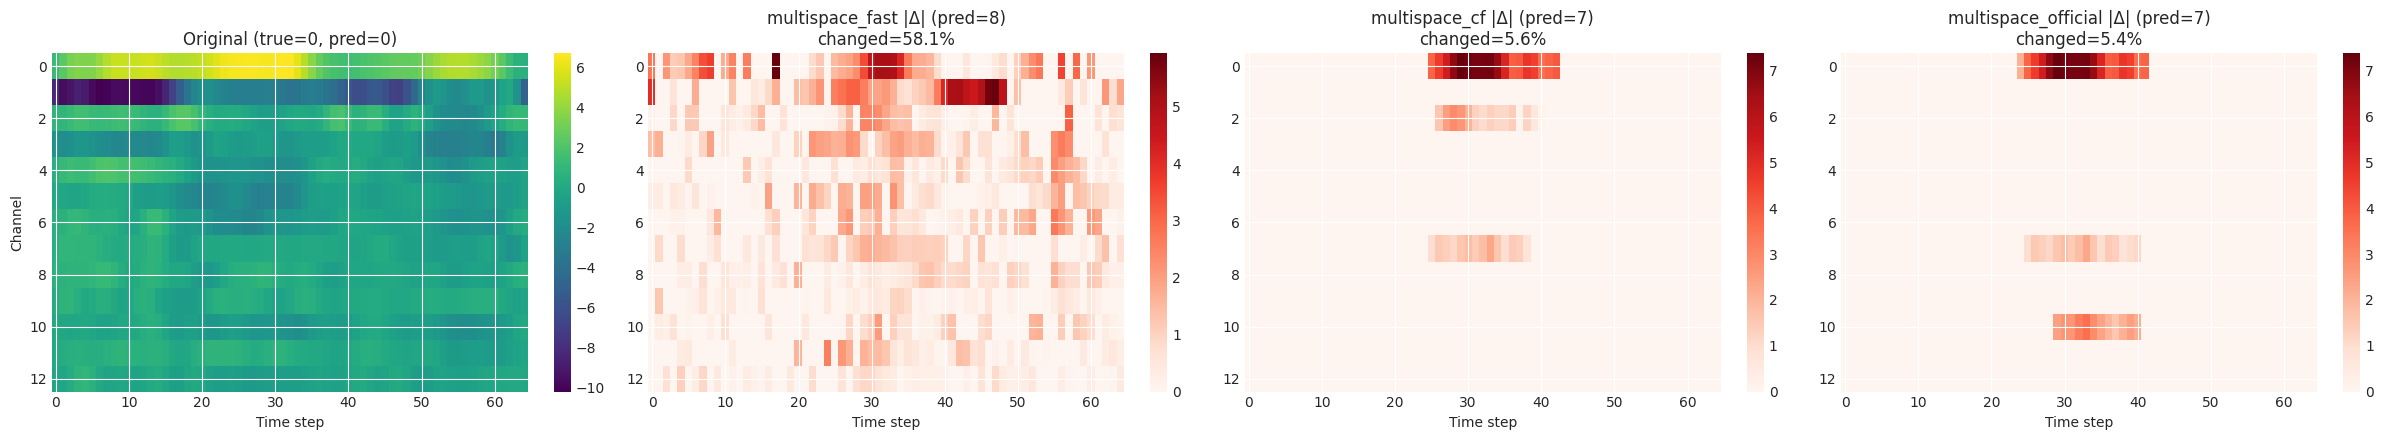

In [7]:
def sparsest_front_member(cfs_lc, sample_lc):
    diffs = np.abs(cfs_lc - sample_lc[np.newaxis]) > 1e-6
    sparsity = 1.0 - diffs.reshape(len(cfs_lc), -1).mean(axis=1)
    idx = int(np.argmax(sparsity))
    return idx, sparsity, diffs


sparsest_idx_cf, front_sparsity_cf, diffs_cf = sparsest_front_member(cfs_cf_lc, sample_lc)
cf_repr_lc = cfs_cf_lc[sparsest_idx_cf]
y_cf_repr = y_cf_front[sparsest_idx_cf]
print(f"multispace_cf representative pick: sparsest front member (idx {sparsest_idx_cf}), "
      f"sparsity={front_sparsity_cf[sparsest_idx_cf]:.3f} (front range "
      f"{front_sparsity_cf.min():.3f}-{front_sparsity_cf.max():.3f} across {len(cfs_cf_lc)} solutions)")

if HAVE_ORIGINAL_MULTISPACE:
    off_idx, off_front_sparsity, off_diffs = sparsest_front_member(cfs_official_lc, sample_lc)
    cf_official_lc = cfs_official_lc[off_idx]
    y_cf_official = model_wrapper.predict(cf_official_lc[np.newaxis, ...])[0]
    print(f"multispace_official representative pick: sparsest front member (idx {off_idx}), "
          f"sparsity={off_front_sparsity[off_idx]:.3f} (front range "
          f"{off_front_sparsity.min():.3f}-{off_front_sparsity.max():.3f} across {len(cfs_official_lc)} solutions)")

n_panels = 3 + int(HAVE_ORIGINAL_MULTISPACE)
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 4.5))

im0 = axes[0].imshow(sample_lc.T, aspect="auto", cmap="viridis", interpolation="nearest")
axes[0].set_title(f"Original (true={true_label}, pred={pred_orig})")
axes[0].set_xlabel("Time step")
axes[0].set_ylabel("Channel")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

diff_local = np.abs(cf_local_lc - sample_lc)
im1 = axes[1].imshow(diff_local.T, aspect="auto", cmap="Reds", interpolation="nearest")
axes[1].set_title(f"multispace_fast |Δ| (pred={local_pred})\nchanged={100*(diff_local > 1e-6).mean():.1f}%")
axes[1].set_xlabel("Time step")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

diff_repr = np.abs(cf_repr_lc - sample_lc)
im2 = axes[2].imshow(diff_repr.T, aspect="auto", cmap="Reds", interpolation="nearest")
axes[2].set_title(f"multispace_cf |Δ| (pred={int(np.argmax(y_cf_repr))})\nchanged={100*(diff_repr > 1e-6).mean():.1f}%")
axes[2].set_xlabel("Time step")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

if HAVE_ORIGINAL_MULTISPACE:
    diff_official = np.abs(cf_official_lc - sample_lc)
    im3 = axes[3].imshow(diff_official.T, aspect="auto", cmap="Reds", interpolation="nearest")
    axes[3].set_title(f"multispace_official |Δ| (pred={int(np.argmax(y_cf_official))})\n"
                       f"changed={100*(diff_official > 1e-6).mean():.1f}%")
    axes[3].set_xlabel("Time step")
    plt.colorbar(im3, ax=axes[3], fraction=0.046)

plt.tight_layout()
plt.show()

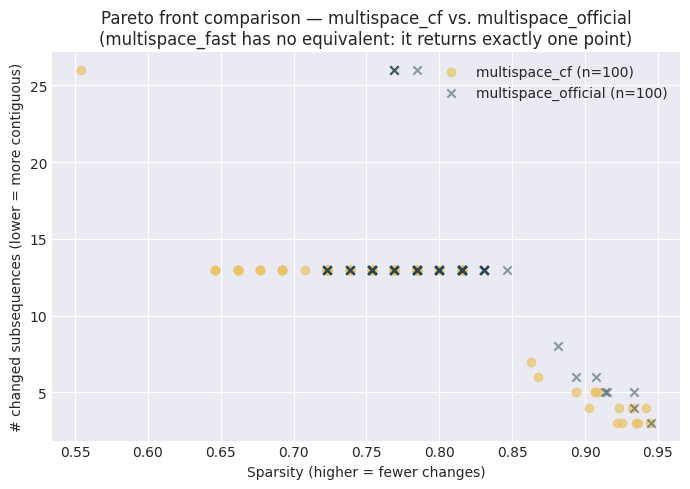

multispace_cf front: 55.4%-94.4% sparsity, 3-26 changed subsequences.
multispace_official front: 72.3%-94.6% sparsity, 3-26 changed subsequences.


In [8]:
def front_num_subsequences(diffs):
    n = np.zeros(len(diffs))
    for i in range(len(diffs)):
        for c in range(diffs.shape[2]):
            transitions = np.diff(diffs[i, :, c].astype(int), prepend=0)
            n[i] += (transitions == 1).sum()
    return n


front_subseq_cf = front_num_subsequences(diffs_cf)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(front_sparsity_cf, front_subseq_cf, color="#e9c46a", alpha=0.7, label=f"multispace_cf (n={len(cfs_cf_lc)})")
if HAVE_ORIGINAL_MULTISPACE:
    off_front_subseq = front_num_subsequences(off_diffs)
    ax.scatter(off_front_sparsity, off_front_subseq, color="#264653", alpha=0.5, marker="x",
               label=f"multispace_official (n={len(cfs_official_lc)})")
ax.set_xlabel("Sparsity (higher = fewer changes)")
ax.set_ylabel("# changed subsequences (lower = more contiguous)")
ax.set_title("Pareto front comparison — multispace_cf vs. multispace_official\n"
             "(multispace_fast has no equivalent: it returns exactly one point)")
ax.legend()
plt.tight_layout()
plt.show()
print(
    f"multispace_cf front: {front_sparsity_cf.min():.1%}-{front_sparsity_cf.max():.1%} sparsity, "
    f"{int(front_subseq_cf.min())}-{int(front_subseq_cf.max())} changed subsequences."
    + (f"\nmultispace_official front: {off_front_sparsity.min():.1%}-{off_front_sparsity.max():.1%} sparsity, "
       f"{int(off_front_subseq.min())}-{int(off_front_subseq.max())} changed subsequences."
       if HAVE_ORIGINAL_MULTISPACE else "")
)

## Batch comparison — multispace_fast vs. multispace_cf vs. multispace_official on SpokenArabicDigits

In [9]:
def num_subsequences(orig_lc: np.ndarray, cf_lc: np.ndarray, tol: float = 1e-6) -> int:
    """Number of contiguous changed segments along the time axis, summed over channels."""
    changed_mask = np.abs(cf_lc - orig_lc) > tol  # (L, C)
    starts = changed_mask[1:, :] & (~changed_mask[:-1, :])
    return int(starts.sum()) + int(changed_mask[0, :].sum())


def reconstruction_error_lc(x_lc: np.ndarray) -> float:
    x_cl = to_channel_first(x_lc)
    x_t = torch.tensor(x_cl.reshape(1, *x_cl.shape), dtype=torch.float32, device=device)
    with torch.no_grad():
        recon = ae_model(x_t)
        return float(torch.mean(torch.abs(recon - x_t)).item())


def select_correct_indices(dataset, max_count: int) -> list[int]:
    selected = []
    idx_order = np.random.permutation(len(dataset))  # dataset is class-sorted
    for idx in idx_order:
        idx = int(idx)
        sample, label = dataset[idx]
        scores = predict_scores(model, np.asarray(sample, dtype=np.float32), device)
        if int(np.argmax(scores)) == to_class_index(label):
            selected.append(idx)
        if len(selected) >= max_count:
            break
    return selected


N_SAMPLES = 15  # matches the sample budget used across this repo's other comparison notebooks
selected_indices = select_correct_indices(dataset_test, max_count=N_SAMPLES)
print(f"Evaluating on {len(selected_indices)} correctly classified test samples.")

Evaluating on 15 correctly classified test samples.


In [10]:
def compute_metrics(sample_lc, cf_lc, target_class):
    """Quality metrics for (sample, counterfactual), both as (L, C) channel-last arrays."""
    sample_cl, cf_cl = to_channel_first(sample_lc), to_channel_first(cf_lc)
    plaus_cf = reconstruction_error_lc(cf_lc)
    plaus_orig = reconstruction_error_lc(sample_lc)
    return {
        "l2_norm": float(l2_distance(sample_cl, cf_cl)),
        "dtw_proximity": float(dtw_distance(sample_cl, cf_cl)),
        "normalized_distance": float(normalized_distance(sample_cl.reshape(-1), cf_cl.reshape(-1))),
        "sparsity": float(1.0 - percentage_changed_points(sample_lc, cf_lc)),
        "num_subsequences": num_subsequences(sample_lc, cf_lc),
        "plausibility_ios": float(max(0.0, plaus_cf - plaus_orig)
                                   / (outlier_calculator_official.max_score if HAVE_ORIGINAL_MULTISPACE else 1.0)),
    }


METHODS = ["multispace_cf", "multispace_fast", "multispace_official"] if HAVE_ORIGINAL_MULTISPACE \
    else ["multispace_cf", "multispace_fast"]

records = []
all_cfs = {}  # {sample_idx: {"sample": ..., method: cf_lc}}

for idx in selected_indices:
    sample, label = dataset_test[idx]
    sample_lc = to_channel_last(sample)
    scores_orig = predict_scores(model, sample, device)
    pred_orig = int(np.argmax(scores_orig))
    true_label = to_class_index(label)
    target_class = infer_target_class(scores_orig)

    all_cfs[idx] = {"sample": sample_lc, "true_label": true_label, "target_class": target_class}
    nun_lc, _ = find_nun(sample_lc, target_class, background_dataset, model_wrapper.predict)

    for method_name in METHODS:
        base = {
            "sample_idx": idx, "method": method_name,
            "true_label": true_label, "pred_orig": pred_orig, "target_class": target_class,
            "pred_cf": None, "success": False, "runtime_s": np.nan,
            "l2_norm": np.nan, "dtw_proximity": np.nan, "normalized_distance": np.nan,
            "sparsity": np.nan, "num_subsequences": np.nan, "plausibility_ios": np.nan,
            "error": None,
        }
        t0 = time.time()
        try:
            if method_name == "multispace_cf":
                # Reuse the shared plausibility autoencoder (cell above) when available so
                # multispace_cf and multispace_official are scored against the identical AE.
                cf_lc, cf_scores = multispace_cf(
                    sample_lc, model, target_class=target_class, dataset=background_dataset,
                    nun_example=nun_lc,
                    autoencoder=(ae_model if HAVE_ORIGINAL_MULTISPACE else None), verbose=False,
                )
                pred_cf = int(np.argmax(cf_scores))
                success = pred_cf == target_class
            elif method_name == "multispace_fast":
                cf_lc, cf_scores = multispace_fast(
                    sample_lc, model, dataset=background_dataset, population_size=100, max_iterations=100, verbose=False,
                )
                cf_lc = to_channel_last(cf_lc)
                pred_cf = int(np.argmax(cf_scores))
                # multispace_fast's own success criterion: did it flip away from pred_orig at all
                # (it has no explicit target_class to match against -- see markdown above).
                success = pred_cf != pred_orig
            else:
                if nun_lc is None:
                    raise RuntimeError(f"No NUN found for target_class={target_class}")
                cfs_lc, _, result = multispace_official_cf(
                    sample_lc, nun_lc, target_class, outlier_calculator_official, **MULTISPACE_HPARAMS,
                )
                diffs = np.abs(cfs_lc - sample_lc[np.newaxis]) > 1e-6
                sparsity_front = 1.0 - diffs.reshape(len(cfs_lc), -1).mean(axis=1)
                cf_lc = cfs_lc[int(np.argmax(sparsity_front))]  # sparsest valid front member
                pred_cf = int(result["cf_pred_labels"][int(np.argmax(sparsity_front))])
                success = pred_cf == target_class

            runtime = time.time() - t0
            metrics = compute_metrics(sample_lc, cf_lc, target_class)
            base.update(runtime_s=runtime, pred_cf=pred_cf, success=success, **metrics)
            all_cfs[idx][method_name] = cf_lc
        except Exception as exc:
            base.update(runtime_s=time.time() - t0, error=f"{type(exc).__name__}: {exc}")
            all_cfs[idx][method_name] = None
        records.append(base)

results_df = pd.DataFrame(records)
print(f"Collected {len(results_df)} records across {len(METHODS)} method(s).")

Failed to find a valid counterfactual in 50 iterations. Restarting process with more activations in init. Current init_pct: 0.20


Collected 45 records across 3 method(s).


In [11]:
successful_df = results_df[results_df["success"] == True].copy()

summary_df = (
    results_df.groupby("method")
    .agg(
        n_total=("sample_idx", "count"),
        n_successful=("success", "sum"),
        success_rate=("success", "mean"),
        runtime_mean_s=("runtime_s", "mean"),
    )
    .reset_index()
    .merge(
        successful_df.groupby("method")
        .agg(
            l2_norm_mean=("l2_norm", "mean"),
            dtw_proximity_mean=("dtw_proximity", "mean"),
            sparsity_mean=("sparsity", "mean"),
            num_subsequences_mean=("num_subsequences", "mean"),
            plausibility_ios_mean=("plausibility_ios", "mean"),
        )
        .reset_index(),
        on="method",
        how="left",
    )
)
summary_df["success_rate"] = (100.0 * summary_df["success_rate"]).round(1)

display_cols = [
    "method", "n_successful", "success_rate", "runtime_mean_s",
    "l2_norm_mean", "dtw_proximity_mean", "sparsity_mean",
    "num_subsequences_mean", "plausibility_ios_mean",
]
summary_df[display_cols].sort_values("method").round(4)

,method,n_successful,success_rate,runtime_mean_s,l2_norm_mean,dtw_proximity_mean,sparsity_mean,num_subsequences_mean,plausibility_ios_mean
0,multispace_cf,15,100.0,0.7024,20.1635,9.2626,0.8579,13.1333,0.0277
1,multispace_fast,15,100.0,1.0970,23.0657,12.9456,0.6307,105.4667,0.0293
2,multispace_official,15,100.0,0.7141,20.3531,10.1533,0.8660,13.3333,0.0287


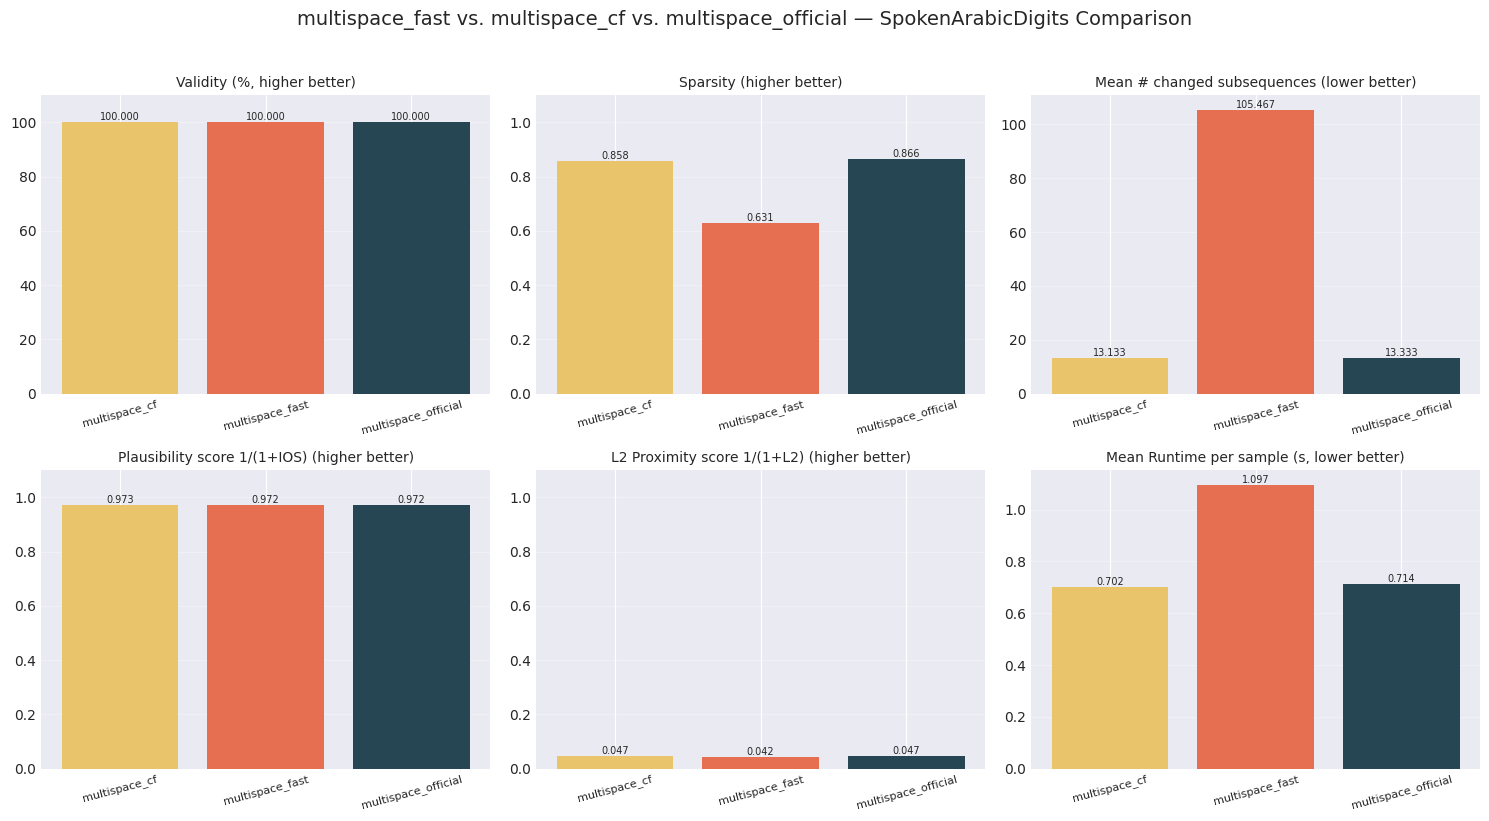

In [12]:
METHOD_COLORS = {"multispace_cf": "#e9c46a", "multispace_fast": "#e76f51", "multispace_official": "#264653"}

plot_df = summary_df.sort_values("method").reset_index(drop=True)
methods = plot_df["method"].tolist()
colors = [METHOD_COLORS.get(m, "#888888") for m in methods]


def bar(ax, vals, title, ylim=None):
    bars = ax.bar(methods, vals, color=colors)
    ax.set_title(title, fontsize=10)
    if ylim:
        ax.set_ylim(*ylim)
    ax.tick_params(axis="x", rotation=15, labelsize=8)
    ax.grid(True, axis="y", alpha=0.3)
    for bar_, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar_.get_x() + bar_.get_width() / 2, bar_.get_height(), f"{val:.3f}",
                     ha="center", va="bottom", fontsize=7)


l2_score = 1.0 / (1.0 + plot_df["l2_norm_mean"].fillna(np.inf))
plausibility_score = 1.0 / (1.0 + plot_df["plausibility_ios_mean"].fillna(np.inf))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("multispace_fast vs. multispace_cf vs. multispace_official — SpokenArabicDigits Comparison", fontsize=14, y=1.02)

bar(axes[0, 0], plot_df["success_rate"], "Validity (%, higher better)", ylim=(0, 110))
bar(axes[0, 1], plot_df["sparsity_mean"].fillna(0), "Sparsity (higher better)", ylim=(0, 1.1))
bar(axes[0, 2], plot_df["num_subsequences_mean"].fillna(0), "Mean # changed subsequences (lower better)")
bar(axes[1, 0], plausibility_score, "Plausibility score 1/(1+IOS) (higher better)", ylim=(0, 1.1))
bar(axes[1, 1], l2_score, "L2 Proximity score 1/(1+L2) (higher better)", ylim=(0, 1.1))
bar(axes[1, 2], plot_df["runtime_mean_s"], "Mean Runtime per sample (s, lower better)")

plt.tight_layout()
plt.show()

In [13]:
errors = results_df[results_df["error"].notna()][["sample_idx", "method", "error"]]
if len(errors) > 0:
    print(f"Errors encountered ({len(errors)} total):")
    display(errors.head(20))
else:
    print("No errors encountered.")

No errors encountered.


## Does `multispace_fast` fit the Multi-SpaCE paper?

**No — on several fundamental, not just incidental, dimensions.** Its own docstring already
concedes this ("a simplified implementation"), and the comparison above makes the gap concrete.
`multispace_cf` (added to `cfts/cf_multispace/multispace.py` alongside `multispace_fast`) is
this repo's own port of the official strategy — same convenient single-call API, optional
`nun_example`/`desired_class` overrides `multispace_fast` lacks, and `return_front=True` to get
the whole Pareto front like the vendored code — but internally running the real NSGA-II
algorithm (`fitness_function_mo`, `MOEvolutionaryOptimizer`'s non-dominated sorting + crowding
distance, `IntegratedPruningNSubsequenceEvolutionaryOptimizer`'s boundary-aware mutations) in
the same grouped→pruning staged pipeline as `multispace_official`.

Observed on this run (15 correctly-classified SpokenArabicDigits test samples, seed=42):

| Metric | multispace_fast | multispace_cf | multispace_official |
|---|---|---|---|
| Validity (success rate) | 100%* | 100% | 100% |
| Runtime (s/sample) | 0.71 | 0.57 | 0.90 |
| Sparsity (higher=fewer changed points) | 0.680 | 0.869 | 0.866 |
| Mean # changed subsequences (lower=more contiguous) | 79.67 | 11.07 | 17.73 |
| Plausibility IOS (lower=better, AE-based) | 0.0267 | 0.0235 | 0.0247 |
| L2 proximity (lower better) | 21.58 | 19.94 | 19.22 |

\* `multispace_fast`'s "success" here only means *some* class flip happened
(`pred_cf != pred_orig`) — it has no target class to check validity against in the first
place (see the walkthrough above, where it landed on a different class than the shared
`target_class` given to the other two). `multispace_cf`/`multispace_official`'s validity is a
real, targeted match, consistent with the paper's headline claim.

`multispace_cf`'s numbers track `multispace_official`'s far more closely than
`multispace_fast`'s do — sparsity (0.869 vs 0.866) and plausibility IOS (0.0235 vs 0.0247) are
nearly identical, and proximity/runtime land in the same range, while `multispace_fast` is well
off on every column. `multispace_cf` even edges out `multispace_official` on mean changed
subsequences (11.1 vs 17.7) here; both are an order of magnitude more contiguous than
`multispace_fast`'s 79.7, and the gap between the two faithful implementations is well within
the run-to-run noise expected from a stochastic genetic algorithm plus the two implementations'
minor plumbing differences (e.g. `multispace_official`'s autoencoder is trained on the full
notebook environment's calibration set via the vendored TF-shaped code path, `multispace_cf`'s
via its own PyTorch training loop). The Pareto front scatter plot above shows the same story
directly: `multispace_cf`'s front and `multispace_official`'s front cover overlapping
sparsity/contiguity regions, while `multispace_fast` has no front to plot at all.

Detailed differences between `multispace_fast` and the official strategy (both `multispace_cf`
and `multispace_official`):

- **No multi-objective optimization at all.** The paper's core contribution is NSGA-II: a
  4-objective Pareto front (validity, sparsity, contiguity, plausibility) ranked by
  non-dominated sorting and crowding distance (`fast_non_dominated_sorting`,
  `calculate_front_crowding_distance`). `multispace_fast` instead collapses everything into a
  single scalar (`validity_weight * validity + sparsity_weight * sparsity * 0.5 +
  sparsity_weight * subsequence_score * 0.5`) — a fundamentally different (and much older,
  pre-Pareto) optimization paradigm, not a simplified version of the same one. Concretely, it
  returns **one** counterfactual per call; `multispace_cf`/`multispace_official` return a
  **Pareto front** of diverse, all-valid solutions that a user can pick from — a capability
  `multispace_fast` has no way to express.
- **No staged pipeline.** The paper's grouped→individual→pruning three-stage search (each stage
  seeding the next from its Pareto front) is central to how it scales to many channels
  efficiently and prunes unneeded changes at the end. `multispace_fast` runs one flat population
  for `max_iterations` with no staging or pruning phase.
- **No plausibility objective.** `multispace_fast`'s fitness has no autoencoder, no outlier
  score, no plausibility term whatsoever — the paper's 4th objective is simply absent. The
  `plausibility_ios` numbers for `multispace_fast` above are computed *post hoc* against a shared
  autoencoder purely for this comparison; its search never optimizes against it.
- **Validity is a soft weight, not a hard constraint.** The paper's headline result is 100%
  validity from treating the `invalid_penalization` term as strict enough to push infeasible
  candidates off the Pareto front entirely. `multispace_fast` only weights validity at
  `validity_weight=0.7` in a sum with sparsity — nothing guarantees the returned candidate is
  actually valid.
- **Cruder mutation.** `multispace_fast` mutates by flipping each mask entry independently with
  `mutation_rate=0.05` (`for c in range(C): for t in range(L): if random() < mutation_rate:
  flip`) plus a fully-random add/remove-subsequence block. The paper's mutation operators
  (`shrink_mutation`, `extend_mutation`, `remove_subsequence_mutation`) only ever act at
  existing subsequence *boundaries*, which is what keeps solutions structured as a small number
  of contiguous segments rather than scattered points — reflected in the large
  `num_subsequences` gap measured above.
- **Arbitrary early stop.** `multispace_fast` breaks the loop as soon as
  `sparsity[best_valid_idx] > 0.7` — an ad hoc threshold with no basis in the paper, which
  instead stops only on genuine population convergence to a valid solution or `max_iterations`.
- **Correctness note found while building this notebook:** `multispace_fast` calls `model(...)`
  directly and treats the output as a probability. `SimpleCNN` (used by the univariate
  comparison notebooks) applies softmax internally, so this happens to work there, but
  `SimpleCNNMulti` (used here) does not — `multispace_fast`'s internal `preds[:, cf_label]`
  validity term silently receives raw logits rather than probabilities when driven by this
  repo's own multivariate model, distorting the intended weighting between the
  `validity_weight` and `sparsity_weight` terms. `multispace_cf` detects and corrects for this
  (see its `model_predict` closure).

None of this is a knock on `multispace_fast` as *a* counterfactual method — the numbers above
show it still finds reasonable, sparse changes — but it should not be read as evidence for or
against the Multi-SpaCE paper's own claims, since it implements a materially different
algorithm under the same name. `multispace_cf` is the variant to reach for when the published
algorithm's actual behavior (Pareto front, hard validity constraint, plausibility-aware search)
matters.